

`Práctica Nº2 - Aprendizaje Profundo`



#**DETECCIÓN DE OBJETOS CON YOLO**

##*DataSet: Kangaroo*

### 00. Librerias

In [ ]:
!pip -q install datasets evaluate albumentations torchmetrics transformers==4.57.6 huggingface_hub accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 12.0 MB/s eta 0:00:00


In [ ]:
import os
import json
import random
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import torch
from PIL import Image, ImageDraw

from datasets import Dataset, DatasetDict
import albumentations as A
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    Trainer,
    TrainingArguments
)
import warnings
warnings.filterwarnings("ignore")


In [ ]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

### 01. Descargar & Reorganizar el DataSet

In [ ]:
%%capture
!rm -rf kangaroo kangaroo-master
!wget -q https://github.com/experiencor/kangaroo/archive/refs/heads/master.zip -O kangaroo.zip
!unzip -q kangaroo.zip
!mv kangaroo-master kangaroo

In [ ]:
random.seed(42)

base_dir = Path("kangaroo")
images = sorted(list(base_dir.rglob("*.jpg")))
xmls = {x.stem: x for x in base_dir.rglob("*.xml")}

valid_images = [img for img in images if img.stem in xmls]
random.shuffle(valid_images)

split_idx = int(0.8 * len(valid_images))
train_imgs = valid_images[:split_idx]
test_imgs = valid_images[split_idx:]

for split in ["train", "test"]:
    (base_dir / split / "images").mkdir(parents=True, exist_ok=True)
    (base_dir / split / "labels").mkdir(parents=True, exist_ok=True)

for split_name, split_imgs in [("train", train_imgs), ("test", test_imgs)]:
    for img_path in split_imgs:
        xml_path = xmls[img_path.stem]
        shutil.copy(img_path, base_dir / split_name / "images" / img_path.name)
        shutil.copy(xml_path, base_dir / split_name / "labels" / xml_path.name)

In [ ]:
print(f"Total imágenes: {len(valid_images)}")
print(f"Train: {len(train_imgs)}")
print(f"Test: {len(test_imgs)}")

Total imágenes: 164
Train: 131
Test: 33


### 02. Pascal VOC a COCO

In [ ]:
class_mapping = {"kangaroo": 0}

def convert_voc_to_coco(voc_dir, coco_output_file):
    coco_format = {
        "info": {"description": "Kangaroo dataset"},
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": [{"id": 0, "name": "kangaroo"}]
    }

    image_id = 0
    annotation_id = 0

    image_folder = Path(voc_dir) / "images"
    label_folder = Path(voc_dir) / "labels"

    for image_file in sorted(image_folder.glob("*.jpg")):
        xml_file = label_folder / f"{image_file.stem}.xml"
        if not xml_file.exists():
            continue

        image_id += 1
        img = Image.open(image_file)
        width, height = img.size

        coco_format["images"].append({
            "id": image_id,
            "width": width,
            "height": height,
            "file_name": image_file.name
        })

        tree = ET.parse(xml_file)
        root = tree.getroot()

        for obj in root.iter("object"):
            class_name = obj.find("name").text.strip()
            if class_name not in class_mapping:
                continue

            bndbox = obj.find("bndbox")
            xmin = int(float(bndbox.find("xmin").text))
            ymin = int(float(bndbox.find("ymin").text))
            xmax = int(float(bndbox.find("xmax").text))
            ymax = int(float(bndbox.find("ymax").text))

            bbox_width = xmax - xmin
            bbox_height = ymax - ymin

            annotation_id += 1
            coco_format["annotations"].append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": class_mapping[class_name],
                "bbox": [xmin, ymin, bbox_width, bbox_height],
                "area": bbox_width * bbox_height,
                "iscrowd": 0
            })

    with open(coco_output_file, "w") as f:
        json.dump(coco_format, f, indent=2)

convert_voc_to_coco("kangaroo/train", "kangaroo_annotations_train.json")
convert_voc_to_coco("kangaroo/test", "kangaroo_annotations_test.json")
print("Archivos COCO creados correctamente.")

Archivos COCO creados correctamente.


### 03. DataSets en Hugging Face

In [ ]:
def load_coco_dataset(image_dir, annotation_file):
    with open(annotation_file, "r") as f:
        coco_data = json.load(f)

    images = []
    for image_data in coco_data["images"]:
        images.append({
            "image": Image.open(os.path.join(image_dir, image_data["file_name"])).convert("RGB"),
            "image_id": image_data["id"],
            "width": image_data["width"],
            "height": image_data["height"]
        })

    image_annotations = {}
    for ann in coco_data["annotations"]:
        image_annotations.setdefault(ann["image_id"], []).append({
            "bbox": ann["bbox"],
            "category_id": ann["category_id"],
            "image_id": ann["image_id"],
            "id": ann["id"],
            "area": ann["area"]
        })

    data = []
    for img in images:
        img["annotations"] = image_annotations.get(img["image_id"], [])
        data.append(img)

    return Dataset.from_list(data)

train_dataset = load_coco_dataset("kangaroo/train/images", "kangaroo_annotations_train.json")
test_dataset = load_coco_dataset("kangaroo/test/images", "kangaroo_annotations_test.json")
dataset = DatasetDict({"train": train_dataset, "test": test_dataset})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'annotations'],
        num_rows: 131
    })
    test: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'annotations'],
        num_rows: 33
    })
})


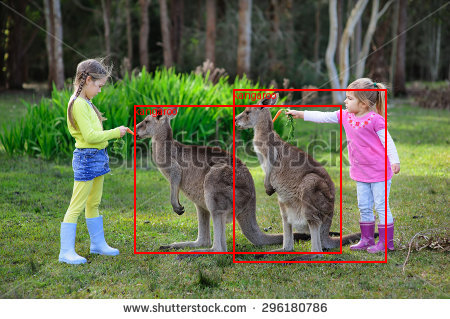

In [ ]:
id2label = {0: "kangaroo"}
label2id = {"kangaroo": 0}

sample = dataset["train"][0]
image = sample["image"].copy()
draw = ImageDraw.Draw(image)

for ann in sample["annotations"]:
    x, y, w, h = ann["bbox"]
    draw.rectangle((x, y, x + w, y + h), outline="red", width=2)
    draw.text((x, y), "kangaroo", fill="red")

image

### 04. Transformaciones & Preprocesado

In [ ]:
checkpoint = "hustvl/yolos-tiny"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
    ],
    bbox_params=A.BboxParams(format="coco", label_fields=["category"])
)

valid_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(format="coco", label_fields=["category"])
)

def formatted_anns(image_id, category, area, bbox):
    return [
        {
            "image_id": image_id,
            "category_id": category[i],
            "isCrowd": 0,
            "area": area[i],
            "bbox": list(bbox[i]),
        }
        for i in range(len(category))
    ]

def transform_examples(examples, transform):
    image_ids = examples["image_id"]
    images, bboxes, areas, categories = [], [], [], []

    for image, objects in zip(examples["image"], examples["annotations"]):
        image_np = np.array(image.convert("RGB"))[:, :, ::-1]
        ann_bboxes = [obj["bbox"] for obj in objects]
        ann_categories = [obj["category_id"] for obj in objects]
        ann_areas = [obj["area"] for obj in objects]

        transformed = transform(
            image=image_np,
            bboxes=ann_bboxes,
            category=ann_categories
        )

        images.append(transformed["image"])
        bboxes.append(transformed["bboxes"])
        categories.append(transformed["category"])

        if len(transformed["bboxes"]) == len(ann_areas):
            areas.append(ann_areas[:len(transformed["bboxes"])])
        else:
            areas.append([box[2] * box[3] for box in transformed["bboxes"]])

    targets = [
        {"image_id": img_id, "annotations": formatted_anns(img_id, cat, ar, box)}
        for img_id, cat, ar, box in zip(image_ids, categories, areas, bboxes)
    ]

    return image_processor(images=images, annotations=targets, return_tensors="pt")

dataset["train"] = dataset["train"].with_transform(lambda x: transform_examples(x, train_transform))
dataset["test"] = dataset["test"].with_transform(lambda x: transform_examples(x, valid_transform))

preprocessor_config.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


### 05. Construir el Modelo YOLO

In [ ]:
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item["labels"] for item in batch]
    return {"pixel_values": encoding["pixel_values"], "labels": labels}

model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)
model

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/26.0M [00:00<?, ?B/s]

Some weights of YolosForObjectDetection were not initialized from the model checkpoint at hustvl/yolos-tiny and are newly initialized because the shapes did not match:
- class_labels_classifier.layers.2.bias: found shape torch.Size([92]) in the checkpoint and torch.Size([2]) in the model instantiated
- class_labels_classifier.layers.2.weight: found shape torch.Size([92, 192]) in the checkpoint and torch.Size([2, 192]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


YolosForObjectDetection(
  (vit): YolosModel(
    (embeddings): YolosEmbeddings(
      (patch_embeddings): YolosPatchEmbeddings(
        (projection): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
      (interpolation): InterpolateInitialPositionEmbeddings()
    )
    (encoder): YolosEncoder(
      (layer): ModuleList(
        (0-11): 12 x YolosLayer(
          (attention): YolosAttention(
            (attention): YolosSelfAttention(
              (query): Linear(in_features=192, out_features=192, bias=True)
              (key): Linear(in_features=192, out_features=192, bias=True)
              (value): Linear(in_features=192, out_features=192, bias=True)
            )
            (output): YolosSelfOutput(
              (dense): Linear(in_features=192, out_features=192, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): YolosIntermediate(
            (dense

### 06. Entrenamiento

In [ ]:
training_args = TrainingArguments(
    output_dir="yolo_kangaroo",
    num_train_epochs=10,
    per_device_train_batch_size=4,
    learning_rate=5e-5,
    weight_decay=1e-4,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
    report_to="none",
    push_to_hub=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=image_processor,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,2.063222
2,No log,1.912734
3,No log,1.085587
4,No log,0.871136
5,No log,0.811450
6,No log,0.768949
7,No log,0.758096
8,No log,0.743665
9,No log,0.745510
10,No log,0.748418


TrainOutput(global_step=330, training_loss=1.1021466804273201, metrics={'train_runtime': 8145.155, 'train_samples_per_second': 0.161, 'train_steps_per_second': 0.041, 'total_flos': 7.31361289743913e+16, 'train_loss': 1.1021466804273201, 'epoch': 10.0})

### 07. Evaluación e Inferencia

In [ ]:
eval_results = trainer.evaluate(dataset["test"])
eval_results

{'eval_loss': 0.7436650991439819,
 'eval_runtime': 92.3632,
 'eval_samples_per_second': 0.357,
 'eval_steps_per_second': 0.054,
 'epoch': 10.0}

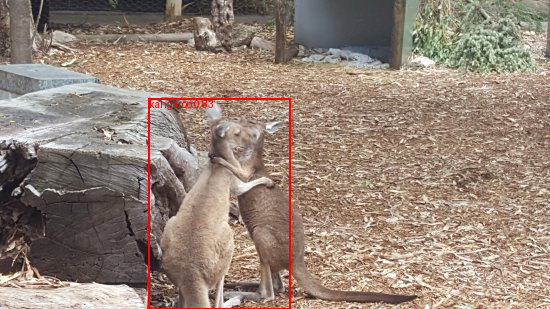

In [ ]:
test_sample_path = sorted(Path("kangaroo/test/images").glob("*.jpg"))[0]
image = Image.open(test_sample_path).convert("RGB")

with torch.no_grad():
    inputs = image_processor(images=[image], return_tensors="pt")
    outputs = model(**inputs)

target_sizes = torch.tensor([[image.size[1], image.size[0]]])
results = image_processor.post_process_object_detection(outputs, threshold=0.5, target_sizes=target_sizes)[0]

draw = ImageDraw.Draw(image)
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    x1, y1, x2, y2 = [round(v, 2) for v in box.tolist()]
    draw.rectangle((x1, y1, x2, y2), outline="red", width=2)
    draw.text((x1, y1), f"{id2label[label.item()]} {score.item():.2f}", fill="red")

image